# Introduction to Jupyter Notebook

In this notebook, we will learn the basic workflow of Jupyter Notebook:
- Running cells and understanding execution order
- Reusing variables across multiple cells
- Working with NumPy and pandas
- Visualizing results quickly
- Debugging errors inside a notebook
- Restarting the session (kernel) and confirming environment versions

In [1]:
import sys
import numpy as np
import pandas as pd

print(f'Python version: {sys.version.split()[0]}')
print(f'NumPy version: {np.__version__}')
print(f'pandas version: {pd.__version__}')

Python version: 3.10.9
NumPy version: 2.1.3
pandas version: 2.2.3


## 1) Basic Notebook Behavior

Cells can be run independently. Variables created in one cell stay in memory for later cells, as long as the kernel is not restarted.

In [2]:
class_scores = np.array([72, 85, 90, 66, 88])
bonus_points = 3

print('Original scores:', class_scores)
print('Bonus points:', bonus_points)

Original scores: [72 85 90 66 88]
Bonus points: 3


In [3]:
# This cell reuses variables from the previous cell.
final_scores = np.clip(class_scores + bonus_points, 0, 100)
print('Final scores:', final_scores)
print('Average final score:', final_scores.mean())

Final scores: [75 88 93 69 91]
Average final score: 83.2


## 2) NumPy Example

NumPy makes numerical calculations concise and fast.

In [4]:
np.random.seed(42)
temperature = np.random.normal(loc=25, scale=3, size=10)

print('Temperatures:', np.round(temperature, 2))
print('Min:', round(temperature.min(), 2))
print('Max:', round(temperature.max(), 2))
print('Std Dev:', round(temperature.std(), 2))

Temperatures: [26.49 24.59 26.94 29.57 24.3  24.3  29.74 27.3  23.59 26.63]
Min: 23.59
Max: 29.74
Std Dev: 2.06


## 3) pandas Example

pandas helps organize and analyze tabular data.

In [5]:
students = pd.DataFrame({
    'name': ['An', 'Binh', 'Chi', 'Dung', 'Em'],
    'subject': ['Math', 'Math', 'Science', 'Science', 'Math'],
    'score': final_scores
})

students

,name,subject,score
0,An,Math,75
1,Binh,Math,88
2,Chi,Science,93
3,Dung,Science,69
4,Em,Math,91


In [6]:
summary = students.groupby('subject', as_index=False)['score'].mean()
summary = summary.rename(columns={'score': 'avg_score'})
summary

,subject,avg_score
0,Math,84.666667
1,Science,81.000000


## 4) Quick Visualization

Visualizing results in notebooks is easy. This example uses matplotlib.

If matplotlib is missing in your environment, install it first with:
`%pip install matplotlib`

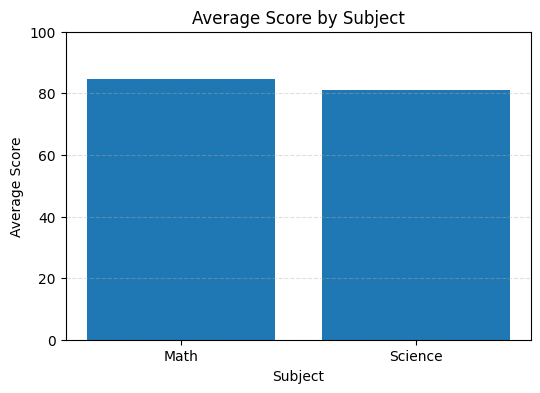

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(summary['subject'], summary['avg_score'])
plt.title('Average Score by Subject')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

## 5) Debugging Example

This example has two debugging targets:
1. An obvious runtime error (KeyError) so students can quickly locate and fix it.
2. A hidden logic bug that produces a wrong average after the error is fixed.
Set breakpoints in `summarize_sales_debug` and inspect `record`, `units`, `price`, `total_revenue`, and `avg_price`.

In [18]:
sales_data = [
    {'product': 'Notebook', 'units': 4, 'unit_price': 2.5},
    {'product': 'Pen', 'units': 10, 'unit_price': 1.2},
    {'product': 'Bag', 'units': 2, 'unit_price': 25.0},
]

def summarize_sales_debug(data):
    total_units = 0
    total_revenue = 0.0

    for record in data:
        # Obvious bug: this key does not exist ('qty' vs 'units').
        units = record.get('units', record.get('qty', 0))
        price = record['unit_price']

        total_units += units
        total_revenue += units * price

    # Hidden bug: average price per unit should divide by total_units, not len(data).
    avg_price = total_revenue / total_units
    return total_units, round(total_revenue, 2), round(avg_price, 2)

summary = summarize_sales_debug(sales_data)
summary

(16, 72.0, 4.5)

In [19]:
assert summary == (16, 72.0, 4.5), "Summary does not match expected values."

## 6) Restarting Session (Kernel) and Confirming State

Try this sequence:
1. Run all previous cells.
2. Restart the kernel from the Notebook menu (Kernel -> Restart Kernel).
3. Students will not be defined

In [20]:
students

,name,subject,score
0,An,Math,75
1,Binh,Math,88
2,Chi,Science,93
3,Dung,Science,69
4,Em,Math,91
